# v3 DF26 -- Monte-Carlo recovery (Figs V1/V2), Colab / M1 runner

A thin demo of the full DF26 pipeline (Sec 12.2 oracle test): train the Block-1 value/policy networks, collect a (parameter, moments) dataset via the batched (GPU-default) Block-2 path, train the moment surrogates, and recover parameters with Levenberg-Marquardt. It then plots **Fig V1** (true vs fitted moments) and **Fig V2** (true vs fitted parameters).

**One knob: the scale `PROFILE`.** Same code at every scale (see `src/v3/profiles.py`).

| profile | grids | sim | collect | use |
|---|---|---|---|---|
| `SMOKE` | 5x5x7 / 9x9x7 | 300x50 | 32 | tests / seconds |
| `MEDIUM` | 7x10x15 / 25x25x15 | 2000x120 | 400 | CPU / M1, minutes |
| `FULL` | 11x15x35 / 81x91x71 | 5000x300 | 10000 | paper grade, a CUDA GPU |

**Device.** `device="auto"` runs the float64 numerics on the GPU under CUDA (Colab: Runtime -> Change runtime type -> GPU) and on the CPU on Apple Metal / no-GPU (float64 has no reliable Metal kernel). `FULL` is intended for a CUDA GPU; on M1 it is an overnight/rented-GPU run.

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  # TFP needs Keras 2 semantics; pin before importing TF

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Pinned stack matching the validated local environment.
    !pip -q install "tensorflow==2.16.2" "tensorflow-probability==0.24.0" "tf-keras==2.16.0"
    # The v3 code lives on branch `v3` (not main); clone that branch. No merge to main needed.
    REPO_URL = "https://github.com/zhaoxuanwang/deep-learning-corp-finance.git"
    BRANCH = "v3"
    REPO_ROOT = "/content/deep-learning-corp-finance"
    if not os.path.exists(REPO_ROOT):
        # Public repo: works as-is. Private repo: use a personal-access token, e.g.
        #   REPO_URL = "https://<GITHUB_TOKEN>@github.com/zhaoxuanwang/deep-learning-corp-finance.git"
        !git clone --branch {BRANCH} --depth 1 {REPO_URL} {REPO_ROOT}
else:
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

import sys
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
print("repo root:", REPO_ROOT, "| Colab:", IN_COLAB)


repo root: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance | Colab: False


In [ ]:
# Confirm the device before a long run: on a Colab GPU runtime this prints the A100; locally it is CPU.
# device="auto" runs the float64 numerics on the GPU under CUDA, on the CPU otherwise.
import tensorflow as tf
gpus = tf.config.list_physical_devices("GPU")
names = []
for g in gpus:
    try:
        names.append(tf.config.experimental.get_device_details(g).get("device_name", g.name))
    except Exception:
        names.append(g.name)
print("GPUs visible to TensorFlow:", names or "none (CPU only)")
print("device='auto' will use:", "GPU (float64 on device)" if gpus else "CPU")

In [2]:
import numpy as np
from src.v3.run import train_and_recover
from src.v3.validation import figures

PROFILE = "MEDIUM"   # "SMOKE" | "MEDIUM" | "FULL"

# Where every output is saved (figures, R^2 tables, arrays, network + surrogate checkpoints),
# so an expensive run never has to be repeated just to recover its outputs. On Colab, point
# this at Google Drive so it survives the runtime being recycled.
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    RESULTS_ROOT = "/content/drive/MyDrive/df26_v3_outputs"
else:
    RESULTS_ROOT = os.path.join(REPO_ROOT, "outputs", "v3")

out = train_and_recover(profile=PROFILE, device="auto", results_root=RESULTS_ROOT, verbose=True)
print("artifacts saved to:", out["run_dir"])


[v3] recover | profile=MEDIUM device=cpu states=1050 train_epochs=30 collect_rows=400 batch=16 draws=20
  recovery draw 1/20 (attempt 1)
  recovery draw 2/20 (attempt 2)
  recovery draw 3/20 (attempt 5)
  recovery draw 4/20 (attempt 6)
  recovery draw 5/20 (attempt 9)
  recovery draw 6/20 (attempt 13)
  recovery draw 7/20 (attempt 14)
  recovery draw 8/20 (attempt 17)
  recovery draw 9/20 (attempt 18)
  recovery draw 10/20 (attempt 20)
  recovery draw 11/20 (attempt 21)
  recovery draw 12/20 (attempt 23)
  recovery draw 13/20 (attempt 24)
  recovery draw 14/20 (attempt 26)
  recovery draw 15/20 (attempt 28)
  recovery draw 16/20 (attempt 29)
  recovery draw 17/20 (attempt 30)
  recovery draw 18/20 (attempt 32)
  recovery draw 19/20 (attempt 33)
  recovery draw 20/20 (attempt 38)
[v3] artifacts saved to /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/v3/df26_recovery/MEDIUM_20260619_231058
artifacts saved to: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/v3/d

In [3]:
print(f"device={out['device']} | profile={out['profile']} | kept draws={out['true_beta'].shape[0]}")
print("surrogate OOS R^2 (mean):", round(float(np.mean(out["surrogate_oos_r2"])), 3))
print("moment   R^2 (mean):", round(float(np.mean(out["moment_r2"])), 3), "  (Fig V1 gate: >= 0.99 at FULL)")
print("param    R^2:", dict(zip(figures.PARAM_NAMES, np.round(out["param_r2"], 3))))
print("           (Fig V2 gate: >= 0.95 for >= 7/8 params; chi is the weak one)")

device=cpu | profile=MEDIUM | kept draws=20
surrogate OOS R^2 (mean): 0.343
moment   R^2 (mean): -1.38   (Fig V1 gate: >= 0.99 at FULL)
param    R^2: {'theta': -0.343, 'rho': -0.013, 'sigma': 0.307, 'delta': -3.059, 'gamma1': -1.233, 'gamma0': -1.467, 'chi': -0.936, 'cf': -0.119}
           (Fig V2 gate: >= 0.95 for >= 7/8 params; chi is the weak one)


### Reading R² and the CI spikes

Each panel's R² is the standard linear-regression coefficient of determination (the squared
correlation between true and fitted), so it lies in `[0, 1]`: 1 is perfect tracking, near 0 is no
relationship. R² does not capture bias or scale; read those off the fixed-range 45-degree plots and
the printed bias/RMSE. A low R² (e.g. `chi`) means weak identification, and its 95% CI spike will be
wide. R² climbs toward the Fig V1 (>= 0.99) / V2 (>= 0.95) gates as the draw count and run scale
(`MEDIUM` -> `FULL`) grow.

In [ ]:
# Figures V1 (moments) and V2 (parameters) from this run.
# (Both are also saved to run_dir/figures by the run above; this just displays them.)
figures.plot_recovery_moments(out)
figures.plot_recovery_params(out)

In [ ]:
# The figures, R^2 tables, arrays, and checkpoints are already saved under run_dir by the run above.
# To regenerate them LATER without re-running the expensive recovery, reload a saved run and call the
# same plot functions (no need to re-plot here):
from src.v3.output.artifacts import load_recovery

reloaded = load_recovery(out["run_dir"])   # or any past run_dir / Drive path
print("reloaded", reloaded["true_beta"].shape[0], "draws; "
      "figures.plot_recovery_moments(reloaded) / plot_recovery_params(reloaded) redraw without rerun.")
# The trained network + surrogate are checkpointed (bundle_ckpt / surrogate_ckpt) and the collected
# dataset is in arrays/dataset.npz, so you can re-estimate or extend without re-collecting.

Block 1 diagnostics (slices vs k/b/z + comparative statics) saved to /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/v3/df26_recovery/MEDIUM_20260619_231058/figures


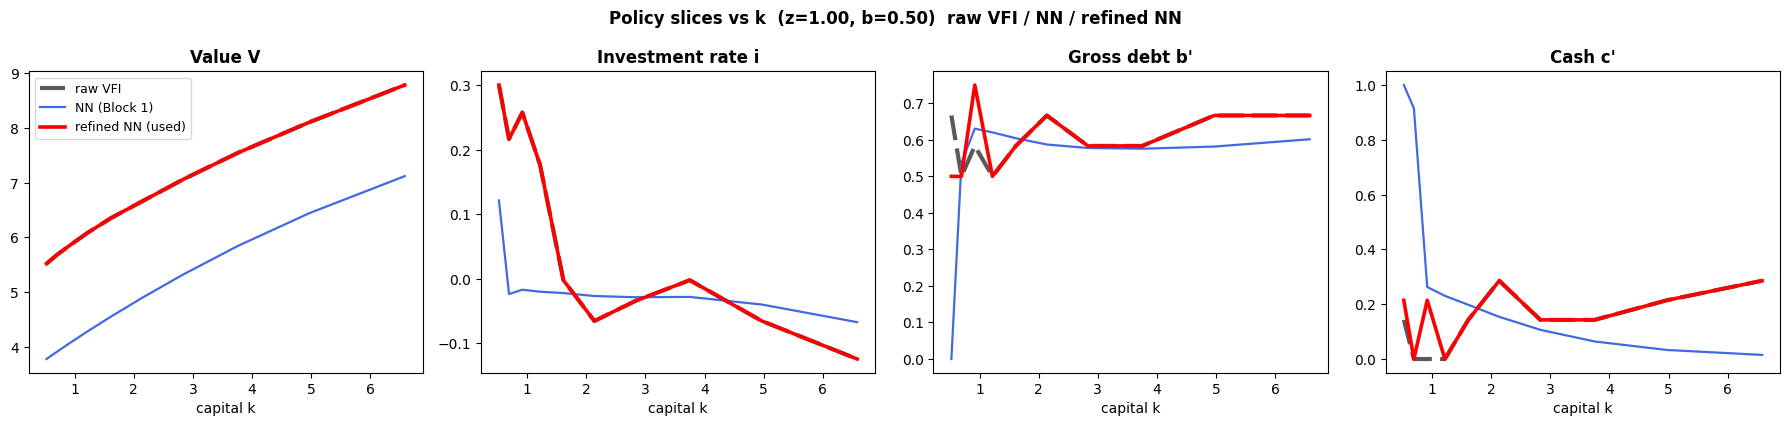

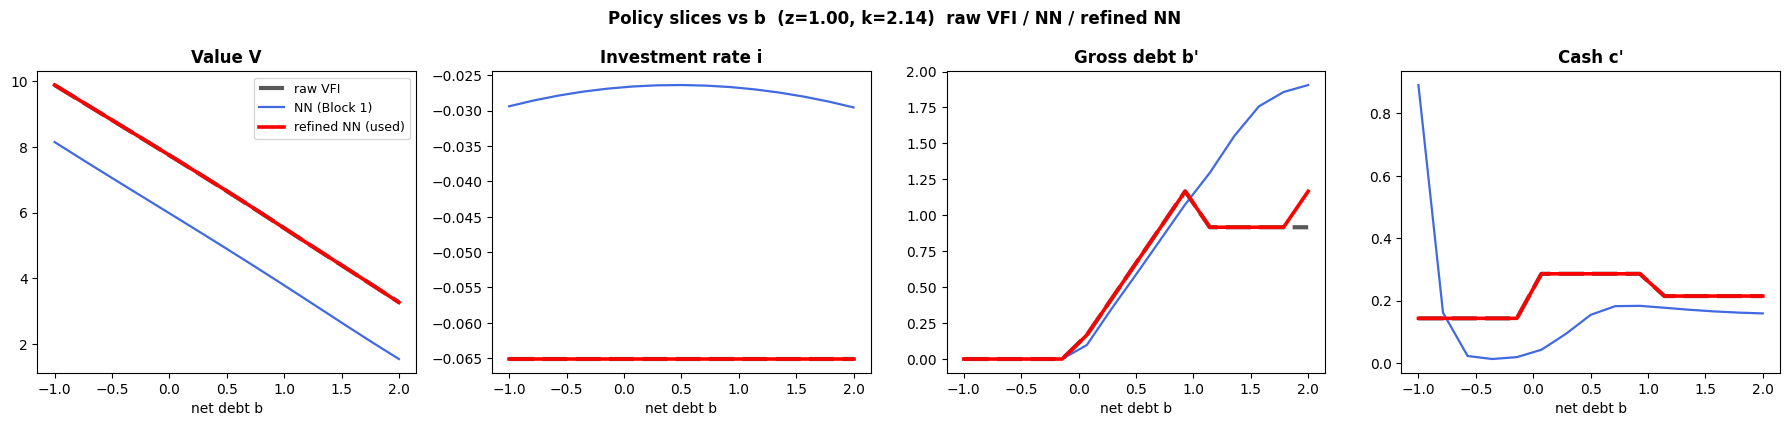

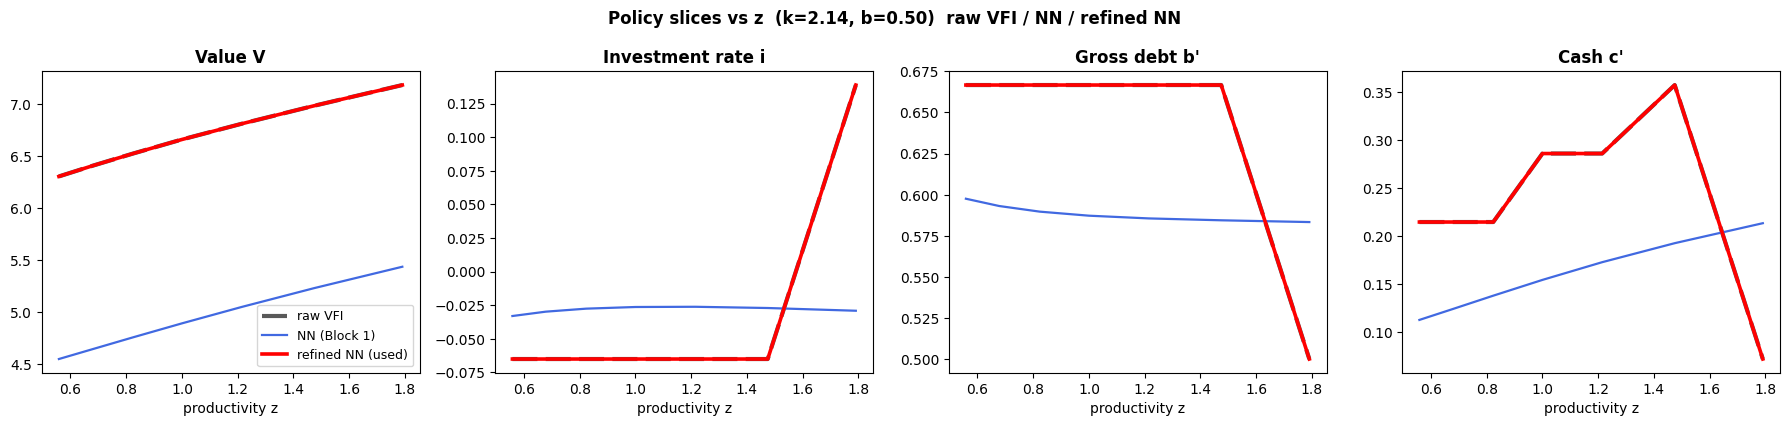

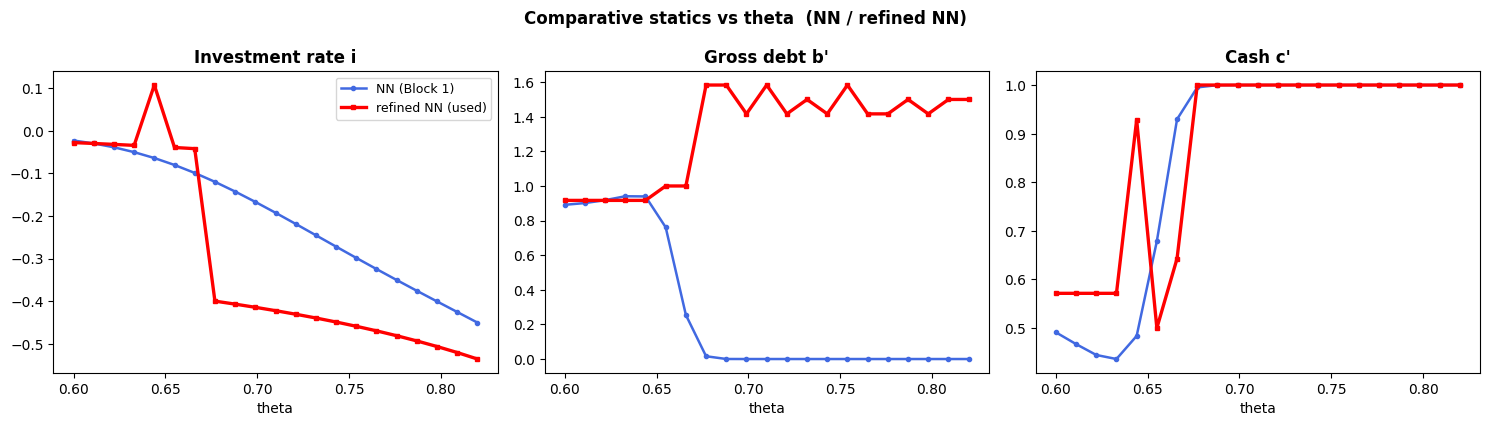

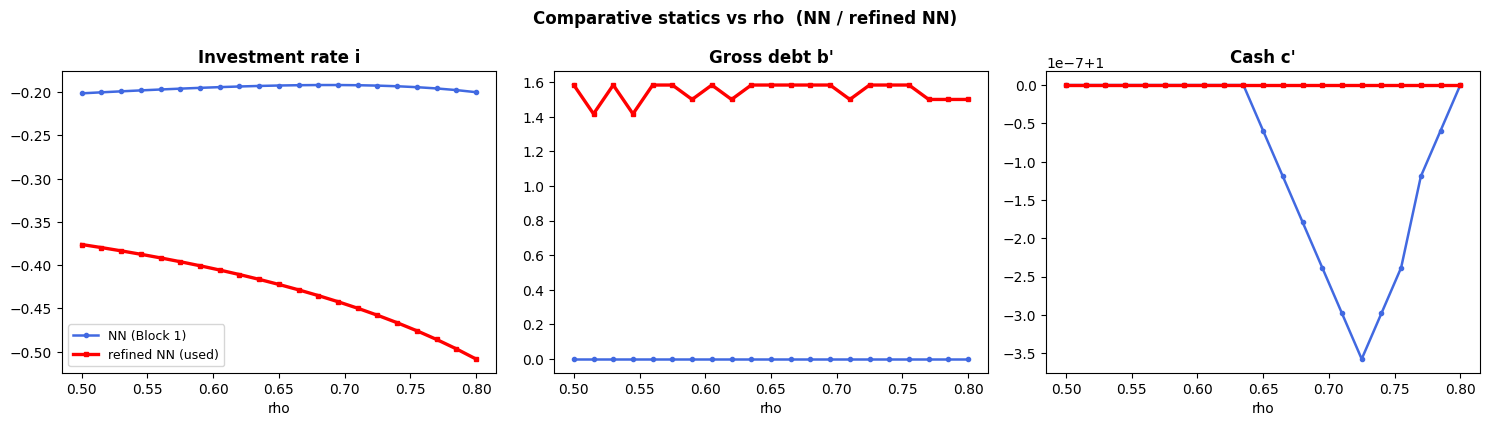

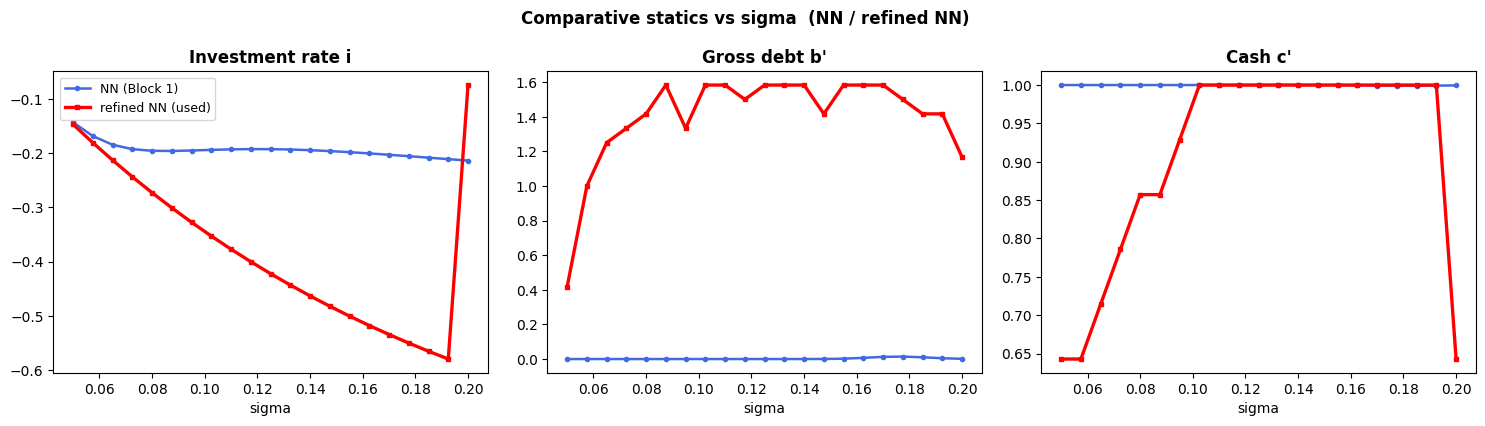

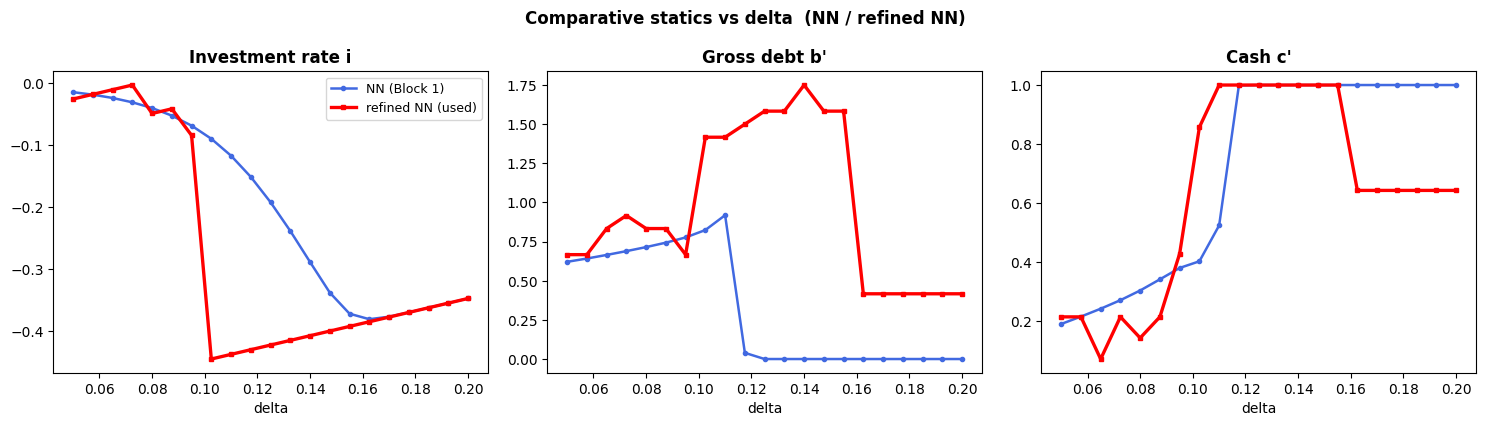

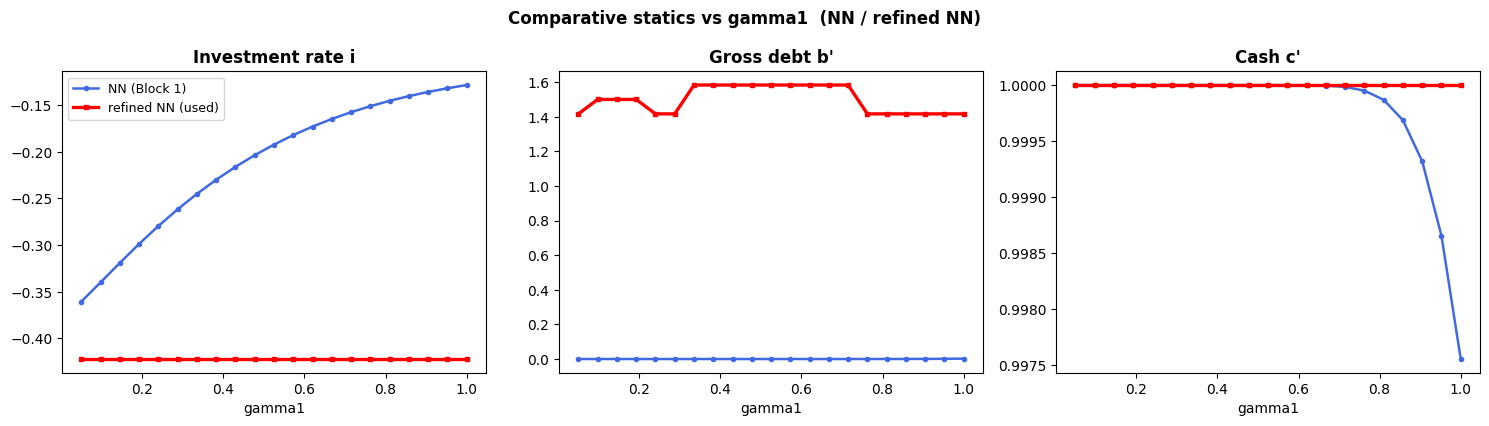

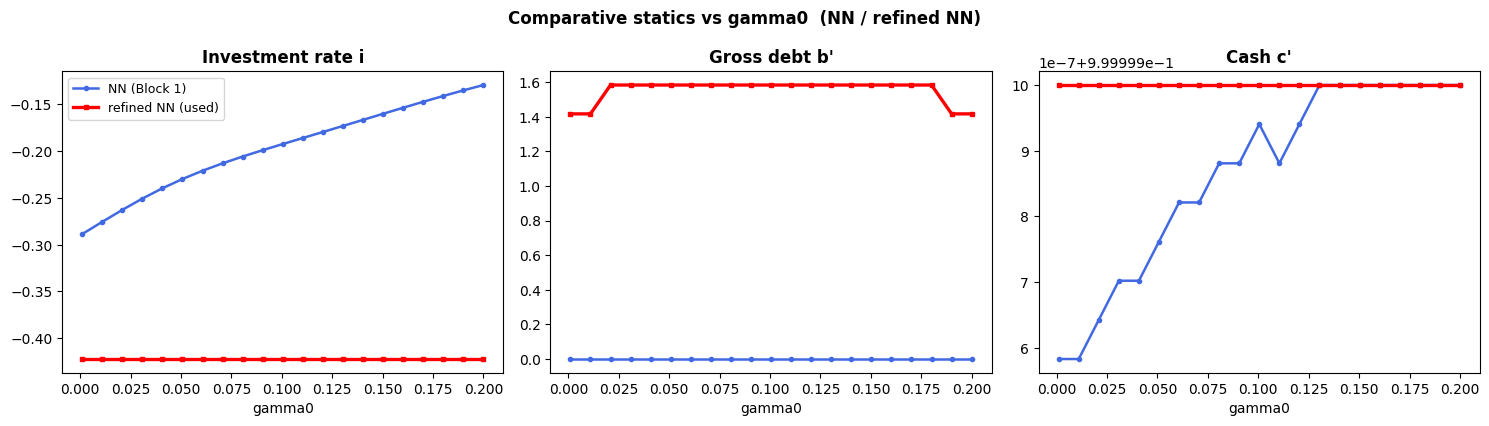

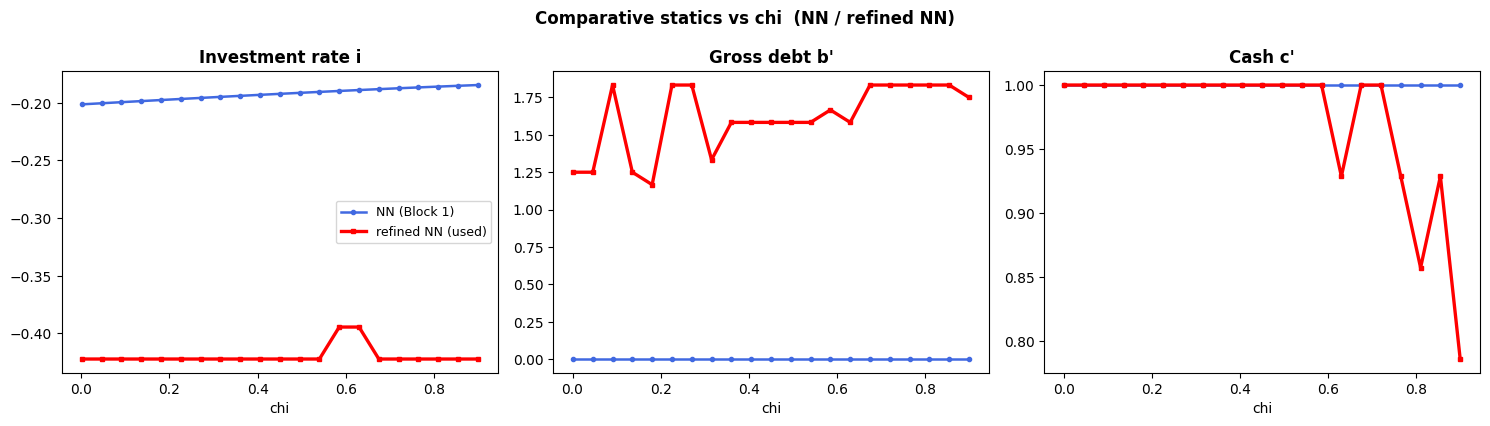

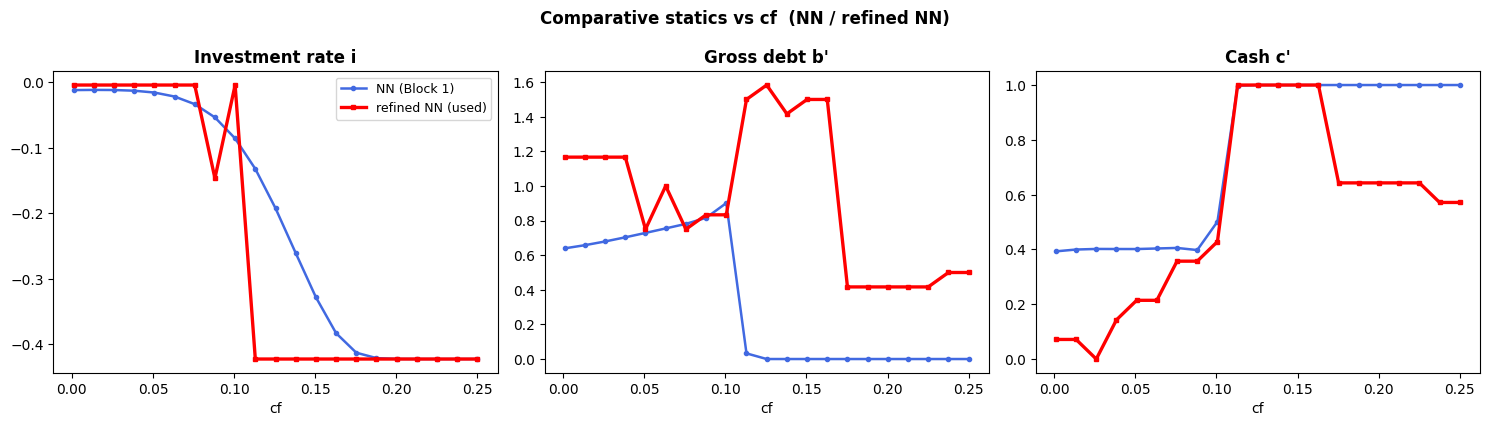

In [7]:
# Block 1 diagnostics from the trained network (latest Block 1 output): complete policy slices
# vs k, b, z, and comparative statics per parameter. Saved next to the recovery artifacts.
# Note: at FULL this adds one VFI solve + a batched refine per parameter; lower n_points to trim cost.
import os
from src.v3 import config as cfg
from src.v3.solver import refine as _refine
from src.v3.validation import vfi as _vfi, evaluate as _ev, policy_slices, comparative

bundle, GRID = out["bundle"], out["grid"]
EXT, BOUNDS, PARAMS = cfg.ExternalParams(), cfg.ParamBounds.table_a1(), cfg.REFERENCE_ESTIMATES
fig_dir = os.path.join(out["run_dir"], "figures")

vfi_sol = _vfi.solve_vfi(PARAMS, EXT, GRID, mode="howard", tol=1e-8, max_sweeps=200)
refined = _refine.refine(bundle, PARAMS, EXT, GRID, BOUNDS, n_rounds=6)
net = _ev.network_on_grid(bundle, PARAMS, EXT, GRID, BOUNDS)

for ax in ("k", "b", "z"):   # raw VFI (thick dash) / NN (blue) / refined NN (bold red, used)
    figures.plot_policy_slices(policy_slices.slices(vfi_sol, net, refined, axis=ax),
                               savepath=os.path.join(fig_dir, f"fig_v3_slices_{ax}.png"))
for pname in cfg.PARAM_NAMES:   # one 1x3 (i, b', c') per parameter, NN + refined NN
    figures.plot_comparative_statics(
        comparative.comparative_statics(bundle, pname, BOUNDS, EXT, GRID, n_points=21),
        savepath=os.path.join(fig_dir, f"fig_comparative_{pname}.png"))
print("Block 1 diagnostics (slices vs k/b/z + comparative statics) saved to", fig_dir)

## Notes

- The Fig V1 (moment R^2 >= 0.99) and Fig V2 (param R^2 >= 0.95 for >= 7/8) acceptance gates are
  expected at `FULL` scale on a GPU; `MEDIUM` lands in the right region but below the paper gates.
  Only the components and the `SMOKE` end-to-end run are validated so far, so a `FULL` run is itself
  the gate verification: confirm at `MEDIUM`, then a reduced `FULL` canary, before an overnight run.

### Which Colab GPU for `FULL`

- **Pick an A100 (Colab Pro+).** This workload is float64-heavy: the dense policy-evaluation solve,
  Levenberg-Marquardt, and the weighting matrix all run in float64. Only datacenter GPUs (A100, V100)
  have full-rate float64; the T4 and L4 cripple float64 (1:32 to 1:64), so they run but the dense
  solves are an order of magnitude slower. The A100's 40 GB also fits the batched `[B, 5775, 5775]`
  solve and the `[B, 5000, 300]` panel.
- **Memory / batch.** `FULL` defaults to `collect_batch_size=8` (safe on 40 GB). On an A100 you can
  push toward 16 for throughput: `train_and_recover(profile="FULL")` after
  `from src.v3.profiles import get_profile` and editing, or pass a tuned profile. Do not raise it on a
  T4/L4.
- **Time.** Expect a multi-hour run (the 10k-row collection dominates). De-risk with a reduced FULL
  first: `train_and_recover("FULL", recovery_draws=4)` to confirm the R^2 trend, then scale up.

- Adaptive controller (Sec 6) demo: `from src.v3.run import run_adaptive_controller`.
- Reproducibility: every run is keyed by `master_seed` (Sec 10).
